## This code is from the tutorial at:
https://quantum.cloud.ibm.com/docs/en/tutorials/loop-string-hadron-dynamics

Modified to run with Quantum Rings SDK

### Install Required Packages

In [ ]:
%%capture
%pip install quantumrings-toolkit-qiskit
%pip install qiskit
%pip install pylatexenc

In [1]:
import time
start_time = time.time_ns() / (10 ** 9)

In [2]:
# Import libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from qiskit.circuit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from typing import Optional

import warnings

warnings.filterwarnings("ignore")

In [3]:
import os
my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"    # This tutorial example works best with scarlet_quantum_rings
my_precision = "double"
my_performance = "AUTOMATIC"

run_options = {"precision": my_precision, "performance": my_performance}

from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrEstimatorV2

service = QrRuntimeService(token = my_token , name = my_name)

run_in_quantum_rings = True

In [4]:
def pair_hamiltonian_circuit(c: float) -> QuantumCircuit:
    """Two-qubit unitary for the approximate interaction Hamiltonian H_I.

    Implements exp(-i * c * H_I^approx) for one pair of neighboring sites,
    where c = delta_tau * x.
    """
    qc_temp = QuantumCircuit(2)
    qc_temp.cx(1, 0)
    qc_temp.h(1)
    qc_temp.rz(-c, 1)
    qc_temp.cx(0, 1)
    qc_temp.rz(c, 1)
    qc_temp.cx(0, 1)
    qc_temp.h(1)
    qc_temp.cx(1, 0)
    return qc_temp


def electric_hamiltonian_circuit(theta: float) -> QuantumCircuit:
    """Two-qubit unitary for the approximate electric field Hamiltonian H_E.

    Implements exp(-i * theta * H_E^approx) for one lattice site,
    where theta = -delta_tau * (n_bar_l / 2 + 3/4).
    """
    qc_temp = QuantumCircuit(2)
    qc_temp.x(0)
    qc_temp.rz(theta / 2, 0)
    qc_temp.cx(0, 1)
    qc_temp.rz(-theta / 2, 1)
    qc_temp.cx(0, 1)
    qc_temp.rz(theta / 2, 1)
    qc_temp.x(0)
    return qc_temp


def construct_circuit(
    num_lattice_point: int,
    num_trotter_steps: int,
    c: float,
    theta: float,
    m: float,
    theory: Optional[int] = 2,
    barriers: Optional[bool] = False,
    measurement: Optional[bool] = False,
    add_init_state: Optional[bool] = True,
    inverse_mid: Optional[bool] = False,
) -> QuantumCircuit:
    """Construct the full Trotterized time-evolution circuit.

    Builds a circuit implementing n Trotter steps of the approximate SU(2)
    LSH Hamiltonian evolution. The qubit layout uses a zigzag ordering:
    n_i(0), n_i(1), n_o(0), n_o(1), n_i(2), n_i(3), n_o(2), n_o(3), ...
    which minimizes the number of SWAP layers needed.

    Args:
        num_lattice_point: Number of lattice sites
        (num_qubits = 2 * num_lattice_point).
        num_trotter_steps: Number of Trotter steps.
        c: Interaction parameter (delta_tau * x).
        theta: Electric field phase parameter.
        m: Mass parameter (m_tilde = delta_tau * mu).
        theory: 1 for single chain, 2 for SU(2). Default 2.
        barriers: Insert barriers between Trotter layers for
        visualization.
        measurement: Append measurements at the end.
        add_init_state: Prepare the half-filled (strong-coupling vacuum)
        initial state.
        inverse_mid: Swap the central sites
        (for differential measurement protocol).
    """
    num_qubits = theory * num_lattice_point
    qc = QuantumCircuit(num_qubits)

    if num_trotter_steps <= 0:
        return qc

    # --- Initial state preparation ---
    if add_init_state:
        i = 1
        while i < num_lattice_point:
            for j in range(theory):
                qc.x(i + j * num_lattice_point)
            i = i + 2
        if inverse_mid:
            mid_lattice_qubits = [num_qubits // 2 - 1, num_qubits // 2]
            qc.x(mid_lattice_qubits)
    else:
        i = 1
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + 4

    # --- Trotter steps ---
    for step in range(num_trotter_steps):
        if barriers:
            qc.barrier()

        # First SWAP layer (skipped at step 0 — absorbed into initial state mapping)
        if step > 0:
            i = 1
            while i < num_qubits - 1:
                qc.swap(i, i + 1)
                i = i + 4

        # First layer of pair interactions
        j = 0
        while j < num_qubits - 2:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)
            j = j + 2
        if num_lattice_point % 2 == 0:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)

        # Second SWAP layer
        i = 1
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + theory

        # Second layer of pair interactions
        j = 2
        while j < num_qubits - 3:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)
            j = j + 2
        if num_lattice_point % 2 != 0:
            circ = pair_hamiltonian_circuit(c)
            qc.compose(circ, [j, j + 1], inplace=True)

        # Third SWAP layer
        i = 3
        while i < num_qubits - 1:
            qc.swap(i, i + 1)
            i = i + 2 * theory

        # Electric field term
        if theta != 0:
            e_circ = electric_hamiltonian_circuit(theta)
            for j in range(num_lattice_point):
                qc.compose(e_circ, [2 * j, 2 * j + 1], inplace=True)

        # Mass term: Rz(-m_tilde) for even sites, Rz(m_tilde) for odd sites
        for q in range(num_qubits):
            if q % 2 == 0:
                qc.rz(-1 * m, q)
            else:
                qc.rz(m, q)

    if measurement:
        qc.measure_all()

    return qc

In [5]:
def get_probabilities(expval: float):
    """Convert a Z-expectation value to site occupation probability.

    Since <Z> = p(0) - p(1), the occupation probability is p(1) = (1 - <Z>) / 2.
    """
    p1 = round((1 - expval) / 2, 3)
    return p1


def get_number(expval_data, num_lattice_point):
    """Convert raw Z-expectation values to staggered fermion number n_f at each site.

    n_f(r) = n_i(r) + n_o(r)           for even r
    n_f(r) = 2 - [n_i(r) + n_o(r)]     for odd r

    The two qubits per site encode (n_i, n_o), and occupation probabilities
    give us <n_i> and <n_o>.
    """
    N = []
    for expvals in expval_data:
        Pstep = [get_probabilities(expval) for expval in expvals]
        Nstep = []
        for k in range(num_lattice_point):
            val = Pstep[2 * k] + Pstep[2 * k + 1]
            a = 2 * (k % 2) + (1 - 2 * (k % 2)) * val
            Nstep.append(float(a))
        N.append(Nstep)
    return N


def calculate_difference(N, N_mid, num_lattice_point):
    """Differential measurement protocol: |n_f(meson) - n_f(vacuum)|.

    Subtracting the vacuum (SCV) evolution from the meson evolution
    isolates the coherent hadron signal from symmetric noise and boundary effects.
    """
    N_diff = []
    for i in range(len(N)):
        Nstep_diff = []
        for j in range(num_lattice_point):
            Nstep_diff.append(abs(N[i][j] - N_mid[i][j]))
        N_diff.append(Nstep_diff)
    return N_diff

In [6]:
# Physical / circuit parameters
num_lattice_point = 6  # 6 lattice sites -> 12 qubits for SU(2)
num_qubits = 2 * num_lattice_point
c = 0.15  # delta_tau * x
theta = 0.01  # electric field phase
m = 0.03  # m_tilde = delta_tau * mu
trotter_steps = range(1, 11)  # 10 Trotter steps

print(f"Lattice sites: {num_lattice_point}, Qubits: {num_qubits}")
print(f"Parameters: c={c}, theta={theta}, m_tilde={m}")

Lattice sites: 6, Qubits: 12
Parameters: c=0.15, theta=0.01, m_tilde=0.03


Circuit for 1 Trotter step: 12 qubits, depth 26


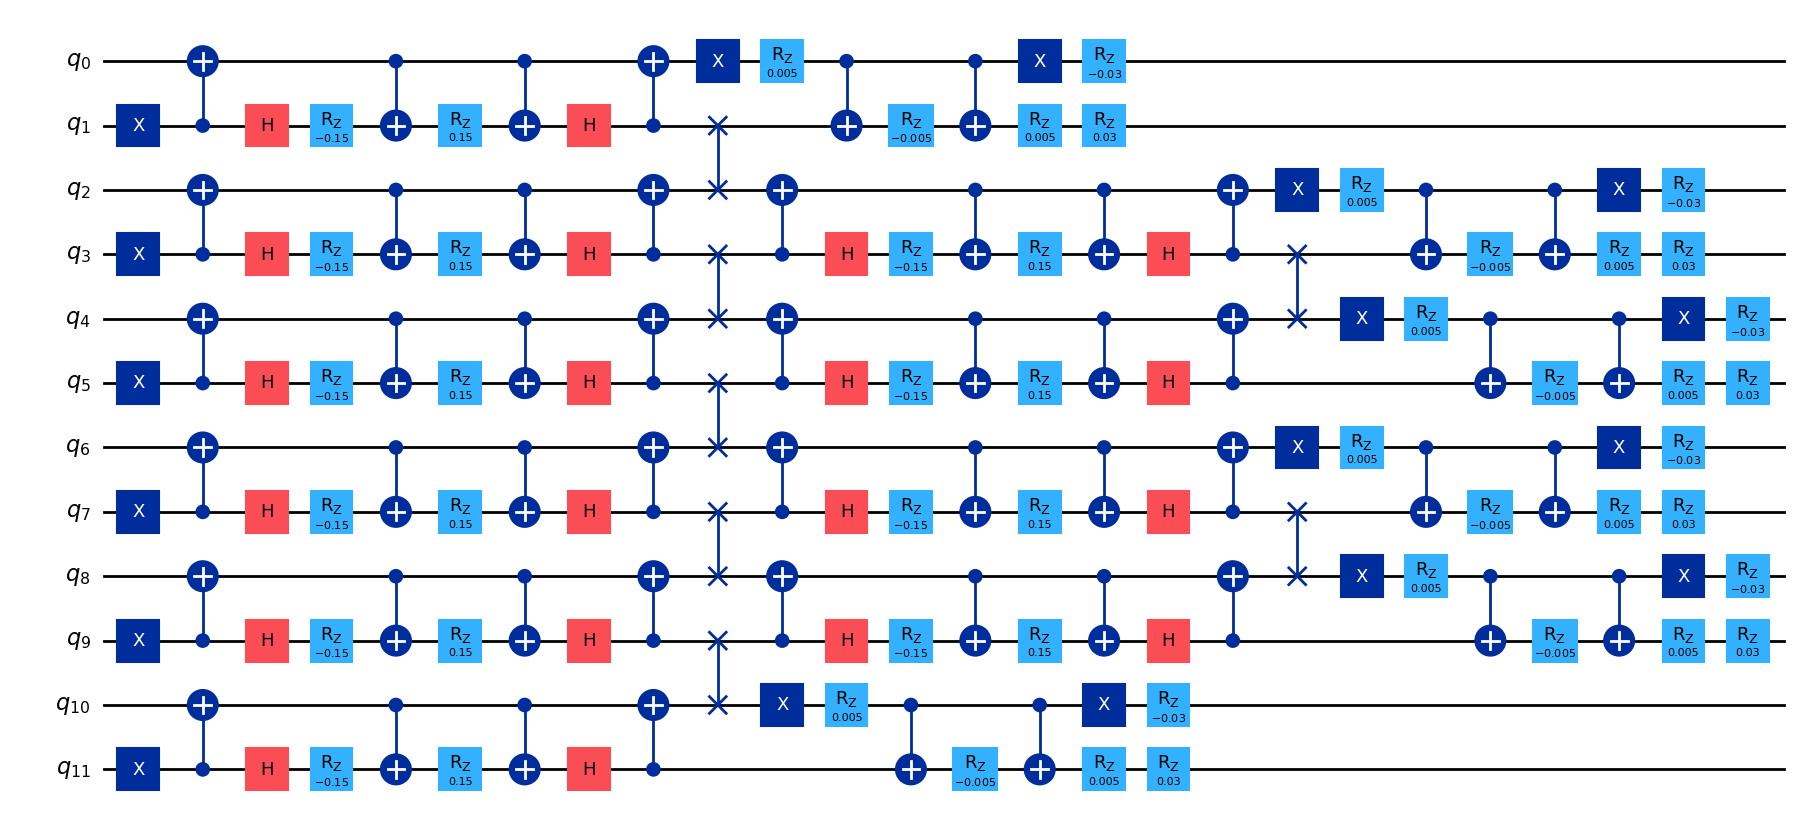

In [7]:
# Build circuits: meson initial state and vacuum (SCV) initial state
circuits_mid = [
    construct_circuit(
        num_lattice_point,
        d,
        c,
        theta,
        m,
        barriers=False,
        measurement=False,
        add_init_state=True,
        inverse_mid=True,
    )
    for d in trotter_steps
]

circuits = [
    construct_circuit(
        num_lattice_point,
        d,
        c,
        theta,
        m,
        barriers=False,
        measurement=False,
        add_init_state=True,
        inverse_mid=False,
    )
    for d in trotter_steps
]

# Visualize a single Trotter step
print(
    f"Circuit for 1 Trotter step: {circuits[0].num_qubits} qubits, depth {circuits[0].depth()}"
)
circuits[0].draw("mpl", fold=-1)

In [8]:
# Z observable on each qubit
observables = [
    SparsePauliOp("I" * i + "Z" + "I" * (num_qubits - i - 1))
    for i in range(num_qubits)
]

print(f"Number of observables: {len(observables)}")

Number of observables: 12


In [9]:
from qiskit.primitives import StatevectorEstimator

if True == run_in_quantum_rings:

    backend = service.backend(name = my_backend, precision = "double", gpu = 0, num_qubits = num_qubits)
    estimator = QrEstimatorV2(backend = backend, run_options = run_options)
else:
    estimator = StatevectorEstimator()

# Run meson circuits
pubs_mid = [(circuit, observables) for circuit in circuits_mid]
result_mid = estimator.run(pubs_mid).result()

# Run vacuum (SCV) circuits
pubs = [(circuit, observables) for circuit in circuits]
result = estimator.run(pubs).result()

# Extract expectation values
raw_expvals_mid = [
    result_mid[i].data.evs[::-1] for i in range(len(circuits_mid))
]
raw_expvals = [result[i].data.evs[::-1] for i in range(len(circuits))]

print(f"Computed expectation values for {len(raw_expvals)} Trotter steps")

Computed expectation values for 10 Trotter steps


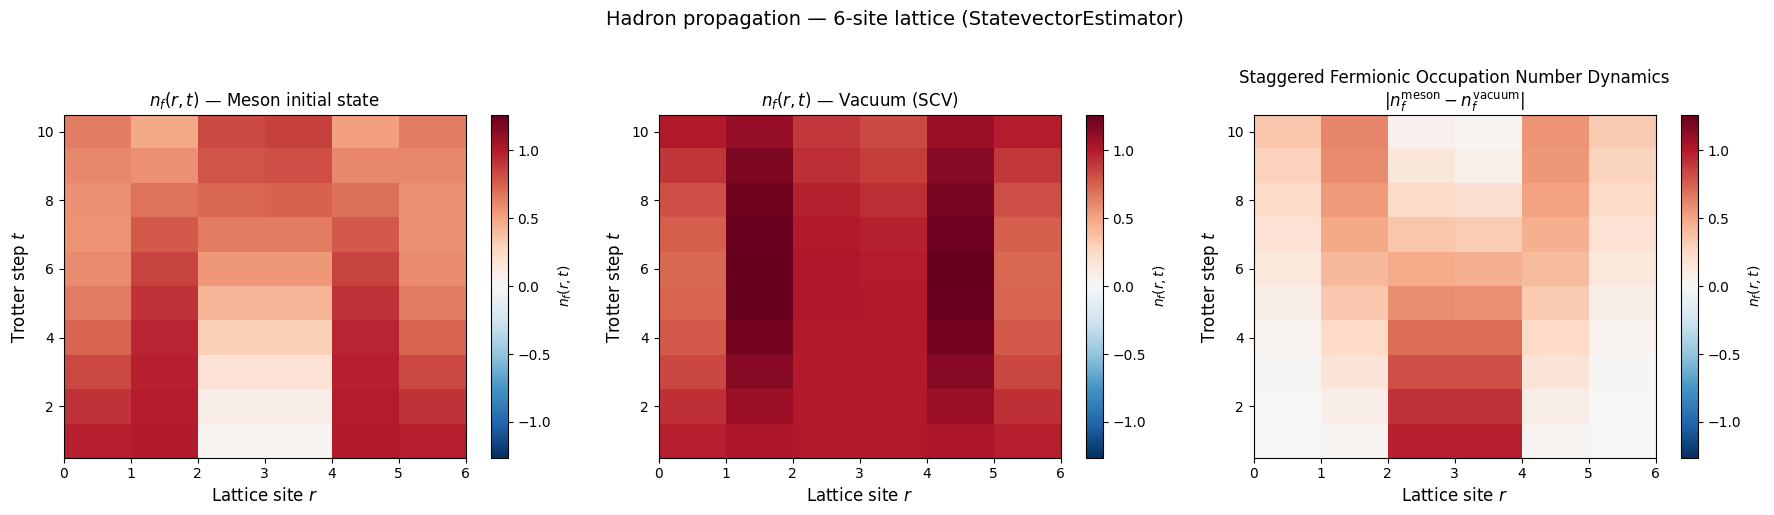

In [10]:
# Compute fermion numbers
N_mid_sim = get_number(raw_expvals_mid, num_lattice_point)
N_sim = get_number(raw_expvals, num_lattice_point)
N_diff_sim = calculate_difference(N_mid_sim, N_sim, num_lattice_point)

# --- Reproduce Figure 3 style: Staggered Fermionic Occupation Number Dynamics ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Convert to numpy arrays for plotting
N_mid_arr = np.array(N_mid_sim)
N_arr = np.array(N_sim)
N_diff_arr = np.array(N_diff_sim)

# Color scheme
vmax = max(max(sublist) for sublist in N_arr)
vmin = -vmax

# Meson evolution
norm1 = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
im0 = axes[0].imshow(
    N_mid_arr,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    norm=norm1,
    extent=[0, num_lattice_point, 0.5, len(trotter_steps) + 0.5],
)
axes[0].set_xlabel("Lattice site $r$", fontsize=12)
axes[0].set_ylabel("Trotter step $t$", fontsize=12)
axes[0].set_title("$n_f(r,t)$ — Meson initial state", fontsize=12)
plt.colorbar(im0, ax=axes[0], label="$n_f(r,t)$")

# Vacuum (SCV) evolution
im1 = axes[1].imshow(
    N_arr,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    norm=norm1,
    extent=[0, num_lattice_point, 0.5, len(trotter_steps) + 0.5],
)
axes[1].set_xlabel("Lattice site $r$", fontsize=12)
axes[1].set_ylabel("Trotter step $t$", fontsize=12)
axes[1].set_title("$n_f(r,t)$ — Vacuum (SCV)", fontsize=12)
plt.colorbar(im1, ax=axes[1], label="$n_f(r,t)$")

# Differential: meson - vacuum
norm2 = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
im2 = axes[2].imshow(
    N_diff_arr,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    norm=norm2,
    extent=[0, num_lattice_point, 0.5, len(trotter_steps) + 0.5],
)
axes[2].set_xlabel("Lattice site $r$", fontsize=12)
axes[2].set_ylabel("Trotter step $t$", fontsize=12)
axes[2].set_title(
    "Staggered Fermionic Occupation Number Dynamics\n$|n_f^{\\mathrm{meson}} - n_f^{\\mathrm{vacuum}}|$",
    fontsize=12,
)
plt.colorbar(im2, ax=axes[2], label="$n_f(r,t)$")

plt.suptitle(
    f"Hadron propagation — {num_lattice_point}-site lattice (StatevectorEstimator)",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [11]:
# -------------------------Step 1: Define parameters & build circuits-------------------------

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2, Batch
from qiskit_ibm_runtime.options import (
    EstimatorOptions,
    ResilienceOptionsV2,
    TwirlingOptions,
    DynamicalDecouplingOptions,
)

if False == run_in_quantum_rings:
    service = QiskitRuntimeService()

num_lattice_point_hw = 30
num_qubits_hw = 2 * num_lattice_point_hw  # 60 qubits
c_hw = 0.15
theta_hw = 0.01
m_hw = 0.03
trotter_steps_hw = range(1, 11)  # 10 Trotter steps

# Build meson and vacuum circuits
circuits_mid_hw = [
    construct_circuit(
        num_lattice_point_hw,
        d,
        c_hw,
        theta_hw,
        m_hw,
        barriers=False,
        measurement=False,
        add_init_state=True,
        inverse_mid=True,
    )
    for d in trotter_steps_hw
]

circuits_hw = [
    construct_circuit(
        num_lattice_point_hw,
        d,
        c_hw,
        theta_hw,
        m_hw,
        barriers=False,
        measurement=False,
        add_init_state=True,
        inverse_mid=False,
    )
    for d in trotter_steps_hw
]

print(f"Built {len(circuits_hw)} circuit pairs for {num_qubits_hw} qubits")

# -------------------------Step 2: Transpile for hardware-------------------------
# The circuit topology is a linear chain, isomorphic to the device topology.
# We use optimization_level=1 since no routing SWAPs are needed — the transpiler
# only needs to select a low-noise qubit chain and decompose to native gates.

if True == run_in_quantum_rings:
    backend = service.backend(name = my_backend, precision = "double", gpu = 0, num_qubits = num_qubits_hw)
  
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend )
else:
    backend = service.backend("ibm_boston")
    layout = [
        140,
        141,
        142,
        143,
        136,
        123,
        122,
        121,
        116,
        101,
        102,
        103,
        96,
        83,
        82,
        81,
        76,
        61,
        62,
        63,
        64,
        65,
        66,
        67,
        68,
        69,
        78,
        89,
        88,
        87,
        97,
        107,
        106,
        105,
        117,
        125,
        126,
        127,
        137,
        147,
        148,
        149,
        150,
        151,
        152,
        153,
        154,
        155,
        139,
        135,
        134,
        133,
        132,
        131,
        130,
        129,
        118,
        109,
        110,
        111,
    ]

    pm = generate_preset_pass_manager(
    optimization_level=1, backend=backend, initial_layout=layout
    )

isa_circuits_mid = pm.run(circuits_mid_hw)
isa_circuits = pm.run(circuits_hw)

print(f"Transpiled circuits. Example depth: {isa_circuits[0].depth()}")

# Define and layout-map observables
observables_hw = [
    SparsePauliOp("I" * i + "Z" + "I" * (num_qubits_hw - i - 1))
    for i in range(num_qubits_hw)
]

isa_observables_mid = [
    [obs.apply_layout(isa_circuits_mid[i].layout) for obs in observables_hw]
    for i in range(len(isa_circuits_mid))
]
isa_observables = [
    [obs.apply_layout(isa_circuits[i].layout) for obs in observables_hw]
    for i in range(len(isa_circuits))
]

# Build PUBs — interleave meson and vacuum for each Trotter step
isa_pubs_mid = [
    (circ, obs) for circ, obs in zip(isa_circuits_mid, isa_observables_mid)
]
isa_pubs = [(circ, obs) for circ, obs in zip(isa_circuits, isa_observables)]

pubs_to_execute = [
    [isa_pubs_mid[i], isa_pubs[i]] for i in range(len(isa_pubs))
]

# -------------------------Step 3: Execute on hardware-------------------------

twirling_options = TwirlingOptions(
    enable_gates=True,
    enable_measure=True,
    shots_per_randomization="auto",
    strategy="active-circuit",
)

resilience_options = ResilienceOptionsV2(
    measure_mitigation=True,  # TREX readout error mitigation
    zne_mitigation=False,  # ZNE turned off
)

dd_options = DynamicalDecouplingOptions(
    enable=False  # Circuit is sufficiently dense
)

options = EstimatorOptions(
    resilience=resilience_options,
    twirling=twirling_options,
    dynamical_decoupling=dd_options,
    default_shots=10_000,
)

ids = []
results = []


Built 10 circuit pairs for 60 qubits
Transpiled circuits. Example depth: 22


In [12]:
with Batch(backend=backend) as batch:
    for idx, pub in enumerate(pubs_to_execute):
        print(f"Submitting job for Trotter step {idx + 1}", flush=True)
        
        if True == run_in_quantum_rings:
            estimator = QrEstimatorV2(backend = backend, run_options = run_options)
        else:
            estimator = EstimatorV2(mode=batch, options=options)
        
        estimator.skip_transpilation = True
        job = estimator.run(pub)
        ids.append(job.job_id())
        if True == run_in_quantum_rings:
            results.append(job.result())
    batch_id = batch.session_id

job_info = {"ids": ids, "batch_id": batch_id}
print(f"Submitted {len(ids)} jobs. Batch ID: {batch_id}")

Submitting job for Trotter step 1
Submitting job for Trotter step 2
Submitting job for Trotter step 3
Submitting job for Trotter step 4
Submitting job for Trotter step 5
Submitting job for Trotter step 6
Submitting job for Trotter step 7
Submitting job for Trotter step 8
Submitting job for Trotter step 9
Submitting job for Trotter step 10
Submitted 10 jobs. Batch ID: None


In [13]:
# -------------------------Step 4: Post-process results-------------------------
if False == run_in_quantum_rings:
    jobs = [service.job(job_id) for job_id in ids]
    results = [job.result() for job in jobs]

# Extract expectation values (index 0 = meson, index 1 = vacuum)
raw_expvals_mid_hw = [result[0].data.evs[::-1] for result in results]
raw_expvals_hw = [result[1].data.evs[::-1] for result in results]

# Compute fermion numbers and differential
N_mid_hw = get_number(raw_expvals_mid_hw, num_lattice_point_hw)
N_hw = get_number(raw_expvals_hw, num_lattice_point_hw)
N_diff_hw = calculate_difference(N_mid_hw, N_hw, num_lattice_point_hw)

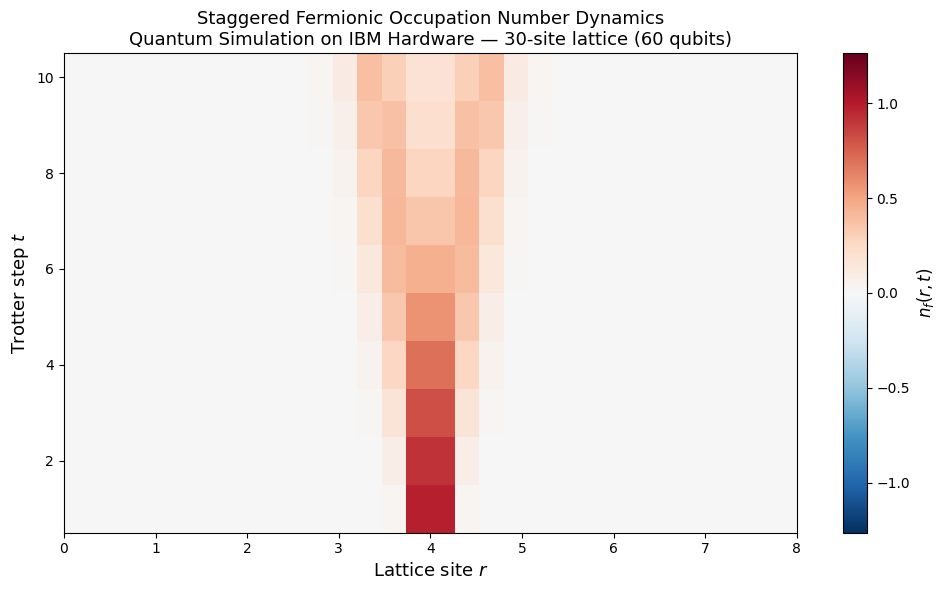

In [14]:
N_diff_hw_arr = np.array(N_diff_hw)

fig, ax = plt.subplots(figsize=(10, 6))
vmax = np.abs(N_hw).max()
vmin = -vmax
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
im = ax.imshow(
    N_diff_hw_arr,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    norm=norm,
    extent=[0, 8, 0.5, len(trotter_steps_hw) + 0.5],
)
ax.set_xlabel("Lattice site $r$", fontsize=13)
ax.set_ylabel("Trotter step $t$", fontsize=13)
ax.set_title(
    "Staggered Fermionic Occupation Number Dynamics\nQuantum Simulation on IBM Hardware — 30-site lattice (60 qubits)",
    fontsize=13,
)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("$n_f(r,t)$", fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
end_time = time.time_ns() / (10 ** 9)
print(f"Time taken = {end_time - start_time}")

Time taken = 615.7437858581543
